<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

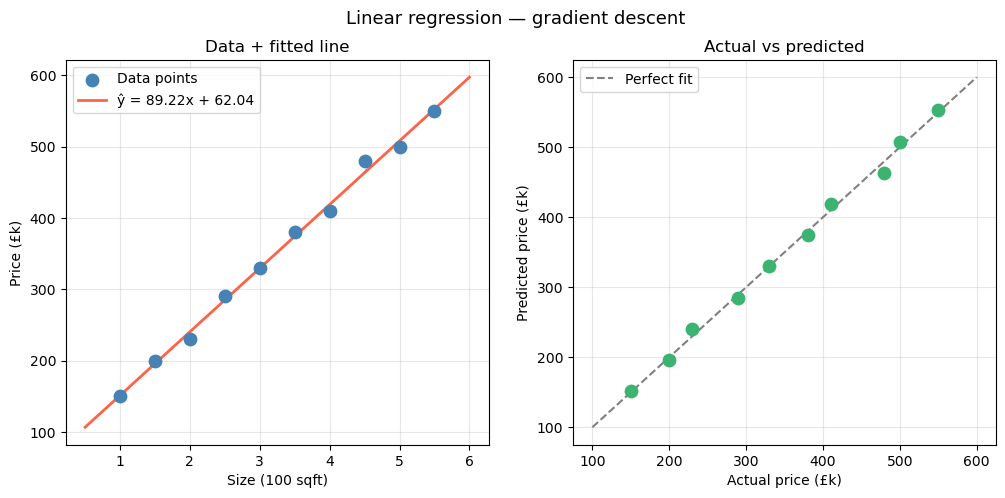

In [1]:
import matplotlib.pyplot as plt

# Data
X = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5]
y = [150, 200, 230, 290, 330, 380, 410, 480, 500, 550]
n = len(X)

# Train
m, b, alpha = 0.0, 0.0, 0.05
for _ in range(500):
    y_pred = [m * X[i] + b      for i in range(n)]
    errors = [y[i] - y_pred[i]  for i in range(n)]
    grad_m = (-2/n) * sum(X[i] * errors[i] for i in range(n))
    grad_b = (-2/n) * sum(errors[i]         for i in range(n))
    m -= alpha * grad_m
    b -= alpha * grad_b

# Final predictions
y_hat = [m * X[i] + b for i in range(n)]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: data + fitted line ---
ax1 = axes[0]
ax1.scatter(X, y, color='steelblue', s=80, zorder=5, label='Data points')
line_x = [0.5, 6.0]
line_y = [m * x + b for x in line_x]
ax1.plot(line_x, line_y, color='tomato', linewidth=2, label=f'ŷ = {m:.2f}x + {b:.2f}')
for i in range(n):
    ax1.plot([X[i], X[i]], [y[i], y_hat[i]], color='gray', linewidth=1,
             linestyle='--', alpha=0.5)
ax1.set_xlabel('Size (100 sqft)')
ax1.set_ylabel('Price (£k)')
ax1.set_title('Data + fitted line')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Right: actual vs predicted ---
ax2 = axes[1]
ax2.scatter(y, y_hat, color='mediumseagreen', s=80, zorder=5)
perfect = [100, 600]
ax2.plot(perfect, perfect, color='gray', linewidth=1.5,
         linestyle='--', label='Perfect fit')
ax2.set_xlabel('Actual price (£k)')
ax2.set_ylabel('Predicted price (£k)')
ax2.set_title('Actual vs predicted')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Linear regression — gradient descent', fontsize=13)
plt.tight_layout